# 04 — Modeling

**Input:** `data/csv/featured_dataset.csv` (03_feature_engineering output)  
**Outputs:** metrics and plots saved under `data/plots/04_modelling/` and `data/model_outputs/`

## Pipeline Summary

```
01_data_loading  ->  combined_dataset.csv   (sampled, balanced)
02_data_cleaning ->  cleaned_dataset.csv    (NaN/Inf/duplicate cleaned)
03_feature_eng   ->  featured_dataset.csv   (correlation/MI filter, label encoded)
04_modeling      ->  Training + Evaluation
```

## Steps

| Step | Operation |
|------|-------|
| 1 | Featured dataset loading |
| 2 | Stratified train/test split |
| 2b | Non-stratified split (comparison) |
| 3 | Binary classification — Random Forest |
| 4 | Multiclass classification — Random Forest |
| **5** | **Multi-Model Comparison — RF vs XGBoost vs CatBoost** |
| 6 | Feature importance |
| 7 | Overfitting risk analysis + time-based holdout |
| 8 | Raw CSV reality check |
| 9 | Comparison table and realistic interpretation |


## Preliminary: Pre vs Post Feature Engineering

Quick sanity check: does feature engineering (03) hurt model performance?
Trains a lightweight RF on the cleaned (pre-FE) dataset vs the featured dataset.
This is a standalone cell with its own imports.


Pre-FE (all features):  features=70,  Acc=0.9901,  F1-Macro=0.8293,  time=1.0s
Post-FE (selected):  features=47,  Acc=0.9908,  F1-Macro=0.8470,  time=0.8s


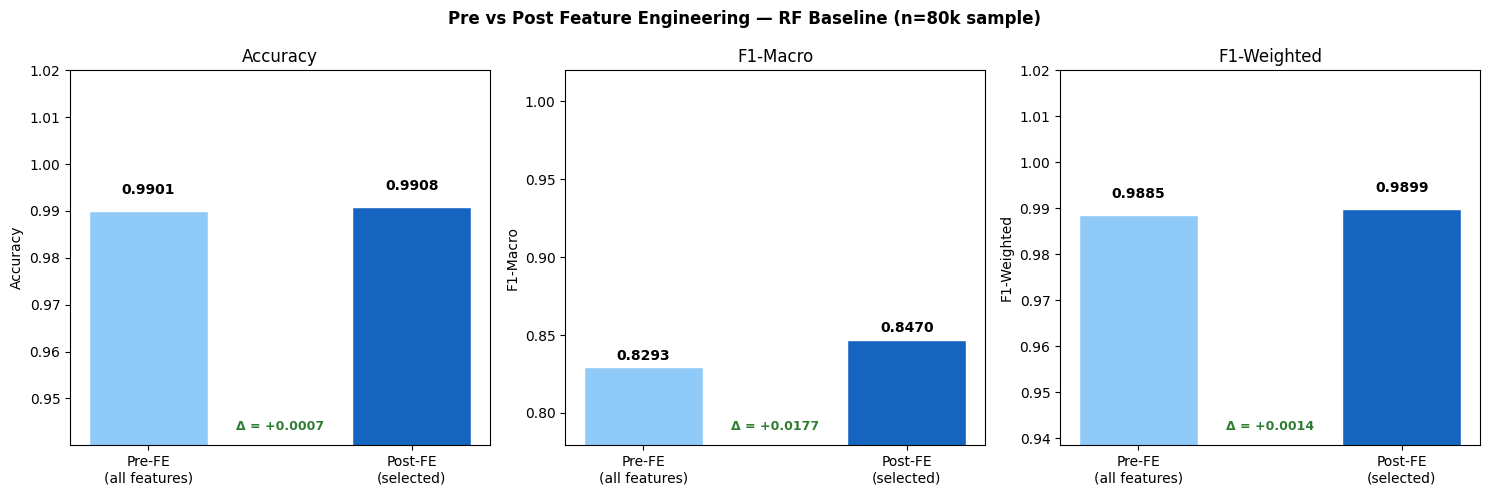


✓ Pre vs Post FE comparison saved to ../data/plots/04_modelling/pre_vs_post_fe_comparison.png


In [1]:
# ── Standalone preliminary comparison (no PLOT_DIR dependency) ────────────
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import os, time

_PLOT_DIR_PRE = "../data/plots/04_modelling"
os.makedirs(_PLOT_DIR_PRE, exist_ok=True)

_RS = 42
_SAMPLE = 80_000

# ── Pre-FE: cleaned_dataset (all numeric features) ───────────────────────
df_pre = pd.read_csv("../data/csv/cleaned_dataset.csv", low_memory=False)
X_pre_all = df_pre.drop(columns=['Label','source_file'], errors='ignore').select_dtypes('number')
from sklearn.preprocessing import LabelEncoder
y_pre_enc = LabelEncoder().fit_transform(df_pre['Label'])

# ── Post-FE: featured_dataset (selected features) ────────────────────────
df_post = pd.read_csv("../data/csv/featured_dataset.csv", low_memory=False)
with open("../data/csv/selected_features.txt") as _f:
    _feat_cols = [l.strip() for l in _f if l.strip()]
X_post = df_post[_feat_cols]
y_post  = df_post['label_multiclass'].values

# ── Sample both to same size ─────────────────────────────────────────────
rng = np.random.RandomState(_RS)
n   = min(_SAMPLE, len(df_pre), len(df_post))
idx_pre  = rng.choice(len(df_pre),  n, replace=False)
idx_post = rng.choice(len(df_post), n, replace=False)

results_pre = {}
for name, X_s, y_s in [
    ('Pre-FE\n(all features)',  X_pre_all.values[idx_pre],  y_pre_enc[idx_pre]),
    ('Post-FE\n(selected)',     X_post.values[idx_post],    y_post[idx_post]),
]:
    Xtr,Xte,ytr,yte = train_test_split(X_s, y_s, test_size=0.2, random_state=_RS, stratify=y_s)
    clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=_RS, n_jobs=-1)
    t0 = time.time()
    clf.fit(Xtr, ytr)
    elapsed = time.time() - t0
    yp = clf.predict(Xte)
    results_pre[name] = dict(
        accuracy   = accuracy_score(yte, yp),
        f1_macro   = f1_score(yte, yp, average='macro',    zero_division=0),
        f1_weighted= f1_score(yte, yp, average='weighted', zero_division=0),
        n_features = X_s.shape[1],
        train_time = elapsed,
    )
    r = results_pre[name]
    print(f"{name.replace(chr(10),' ')}:  features={r['n_features']},  "
          f"Acc={r['accuracy']:.4f},  F1-Macro={r['f1_macro']:.4f},  time={r['train_time']:.1f}s")

# ── Comparison plot ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Pre vs Post Feature Engineering — RF Baseline (n=80k sample)',
             fontsize=12, fontweight='bold')
labels_plt = list(results_pre.keys())
for ax, metric, mname in zip(axes,
    ['accuracy','f1_macro','f1_weighted'],
    ['Accuracy','F1-Macro','F1-Weighted']):
    vals = [results_pre[k][metric] for k in labels_plt]
    bars = ax.bar(labels_plt, vals, color=['#90CAF9','#1565C0'], edgecolor='white', width=0.45)
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    delta = vals[1]-vals[0]
    ax.annotate(f"Δ = {'+' if delta>=0 else ''}{delta:.4f}",
                xy=(0.5,0.04), xycoords='axes fraction', ha='center',
                fontsize=9, fontweight='bold',
                color='#2E7D32' if delta>=0 else '#C62828')
    ax.set_ylim(max(0,min(vals)-0.05), 1.02)
    ax.set_title(mname); ax.set_ylabel(mname)
plt.tight_layout()
plt.savefig(f'{_PLOT_DIR_PRE}/pre_vs_post_fe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ Pre vs Post FE comparison saved to {_PLOT_DIR_PRE}/pre_vs_post_fe_comparison.png')


*(Preliminary cells 3–5 consolidated above)*

In [2]:
pass  # placeholder — merged into preliminary cell above


In [3]:
pass  # placeholder — merged into preliminary cell above


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, time, warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("⚠ xgboost not found — run: pip install xgboost")

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print("⚠ catboost not found — run: pip install catboost")

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# ── Output directories ───────────────────────────────────────────────────────
PLOT_DIR = "../data/plots/04_modelling"
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs('../data/model_outputs', exist_ok=True)

print("=" * 50)
print("Libraries loaded ✓")
print(f"  Pandas   : {pd.__version__}")
print(f"  NumPy    : {np.__version__}")
print(f"  XGBoost  : {'✓' if HAS_XGB else '✗ (install needed)'}")
print(f"  CatBoost : {'✓' if HAS_CAT else '✗ (install needed)'}")
print(f"  Plot dir : {PLOT_DIR}")
print("=" * 50)


Libraries loaded ✓
  Pandas   : 3.0.1
  NumPy    : 2.4.3
  XGBoost  : ✓
  CatBoost : ✓
  Plot dir : ../data/plots/04_modelling


## 1. Dataset Yuekleme

In [5]:
FEATURED_PATH  = "../data/csv/featured_dataset.csv"
FEATURES_TXT   = "../data/csv/selected_features.txt"
LABEL_MAP_PATH = "../data/csv/label_mapping.csv"

with open(FEATURES_TXT) as f:
    FEATURE_COLS = [line.strip() for line in f if line.strip()]

label_mapping = pd.read_csv(LABEL_MAP_PATH)
INT_TO_LABEL  = dict(zip(label_mapping["label_int"], label_mapping["label_string"]))

df = pd.read_csv(FEATURED_PATH, low_memory=False)

print("=" * 65)
print("FEATURED DATASET LOADED")
print("=" * 65)
print(f"  Rows           : {df.shape[0]:>9,}")
print(f"  Features       : {len(FEATURE_COLS)}")
print(f"  Classes        : {df['label_multiclass'].nunique()}")
print()
print("Class distribution:")
for label, cnt in df["Label"].value_counts().items():
    pct = cnt / len(df) * 100
    print(f"  {label:<40} {cnt:>8,}  ({pct:4.1f}%)")
print()
print("Source file distribution:")
for src, cnt in df["source_file"].value_counts().items():
    src_s = src.replace("-WorkingHours","").replace(".pcap_ISCX.csv","")
    print(f"  {src_s:<50} {cnt:>7,}  ({cnt/len(df)*100:4.1f}%)")


FEATURED DATASET LOADED
  Rows           :   495,855
  Features       : 47
  Classes        : 12

Class distribution:
  BENIGN                                    383,341  (77.3%)
  DDoS                                       29,998  ( 6.0%)
  PortScan                                   25,483  ( 5.1%)
  DoS Hulk                                   22,915  ( 4.6%)
  DoS GoldenEye                              10,286  ( 2.1%)
  FTP-Patator                                 5,931  ( 1.2%)
  DoS slowloris                               5,384  ( 1.1%)
  DoS Slowhttptest                            5,228  ( 1.1%)
  SSH-Patator                                 3,219  ( 0.6%)
  Bot                                         1,948  ( 0.4%)
  Web Attack - Brute Force                    1,470  ( 0.3%)
  Web Attack - XSS                              652  ( 0.1%)

Source file distribution:
  Wednesday-workingHours                              91,104  (18.4%)
  Friday-Afternoon-DDos                              

## 2. Train/Test Split

Tum veri seti uzerinde rastgele karistirilarak (shuffle=True) %80 train / %20 test olacak sekilde label dagilimi korunarak bolunur.

In [6]:
TEST_SIZE = 0.20

df_train, df_test = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    shuffle=True, stratify=df["label_multiclass"]
)

X_train = df_train[FEATURE_COLS].values
X_test  = df_test[FEATURE_COLS].values
y_train_mc  = df_train["label_multiclass"].values
y_test_mc   = df_test["label_multiclass"].values
y_train_bin = df_train["label_binary"].values
y_test_bin  = df_test["label_binary"].values

print(f"Train: {len(df_train):>9,} rows")
print(f"Test : {len(df_test):>9,} rows")
print(f"\nBinary — Train benign: {(y_train_bin==0).mean()*100:.1f}%  Test benign: {(y_test_bin==0).mean()*100:.1f}%")

# Dagilim kontrolu
print("\nSplit distribution check:")
tr_vc = pd.Series(y_train_mc).value_counts(normalize=True)*100
te_vc = pd.Series(y_test_mc).value_counts(normalize=True)*100
all_classes = sorted(set(tr_vc.index)|set(te_vc.index))
print(f"  {'Class':<40} {'Train%':>8}  {'Test%':>8}  {'Diff':>6}")
print("-"*68)
for cls in all_classes:
    lbl = INT_TO_LABEL.get(cls, str(cls))
    d = abs(tr_vc.get(cls,0) - te_vc.get(cls,0))
    print(f"  {lbl:<40} %{tr_vc.get(cls,0):>6.2f}   %{te_vc.get(cls,0):>6.2f}   {d:>5.2f}")

Train:   396,684 rows
Test :    99,171 rows

Binary — Train benign: 77.3%  Test benign: 77.3%

Split distribution check:
  Class                                      Train%     Test%    Diff
--------------------------------------------------------------------
  BENIGN                                   % 77.31   % 77.31    0.00
  Bot                                      %  0.39   %  0.39    0.00
  DDoS                                     %  6.05   %  6.05    0.00
  DoS GoldenEye                            %  2.07   %  2.07    0.00
  DoS Hulk                                 %  4.62   %  4.62    0.00
  DoS Slowhttptest                         %  1.05   %  1.05    0.00
  DoS slowloris                            %  1.09   %  1.09    0.00
  FTP-Patator                              %  1.20   %  1.20    0.00
  PortScan                                 %  5.14   %  5.14    0.00
  SSH-Patator                              %  0.65   %  0.65    0.00
  Web Attack - Brute Force                 %  0.30

## 2b. Per-file Split — WITHOUT Stratification

Same 80/20 split but without stratify parameter.
This allows us to measure the impact of stratification on model performance.

**Expected:** Class ratios may differ slightly between train/test,
especially for minority classes (XSS: 652 samples, Bot: 1948 samples).

In [7]:
# ── Per-file split WITHOUT stratification ────────────────────────────────────
df_train_ns, df_test_ns = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    shuffle=True
    # stratify=None  ← intentionally omitted
)

X_train_ns = df_train_ns[FEATURE_COLS].values
X_test_ns  = df_test_ns[FEATURE_COLS].values
y_train_ns_mc  = df_train_ns["label_multiclass"].values
y_test_ns_mc   = df_test_ns["label_multiclass"].values
y_train_ns_bin = df_train_ns["label_binary"].values
y_test_ns_bin  = df_test_ns["label_binary"].values

print("=" * 65)
print("PER-FILE SPLIT — WITHOUT STRATIFICATION")
print("=" * 65)
print(f"  Train: {len(df_train_ns):>9,} rows")
print(f"  Test : {len(df_test_ns):>9,} rows")

# Class ratio comparison
print("\nClass ratio comparison (Train vs Test vs Full):")
tr_vc = pd.Series(y_train_ns_mc).value_counts(normalize=True) * 100
te_vc = pd.Series(y_test_ns_mc).value_counts(normalize=True)  * 100
fs_vc = df["label_multiclass"].value_counts(normalize=True)    * 100

print(f"\n  {'Class':<28} {'Full%':>7} {'Train%':>8} {'Test%':>8} {'Drift':>7}")
print("-" * 62)
for cls in sorted(tr_vc.index):
    lbl  = INT_TO_LABEL.get(cls, str(cls))
    full = fs_vc.get(cls, 0)
    tr   = tr_vc.get(cls, 0)
    te   = te_vc.get(cls, 0)
    drift = abs(te - full)
    flag  = " ⚠" if drift > 0.5 else ""
    print(f"  {lbl:<28} {full:>6.2f}%  {tr:>6.2f}%  {te:>6.2f}%  {drift:>5.2f}%{flag}")

PER-FILE SPLIT — WITHOUT STRATIFICATION
  Train:   396,684 rows
  Test :    99,171 rows

Class ratio comparison (Train vs Test vs Full):

  Class                          Full%   Train%    Test%   Drift
--------------------------------------------------------------
  BENIGN                        77.31%   77.34%   77.18%   0.13%
  Bot                            0.39%    0.39%    0.39%   0.00%
  DDoS                           6.05%    6.05%    6.05%   0.00%
  DoS GoldenEye                  2.07%    2.07%    2.10%   0.03%
  DoS Hulk                       4.62%    4.61%    4.67%   0.04%
  DoS Slowhttptest               1.05%    1.05%    1.06%   0.01%
  DoS slowloris                  1.09%    1.08%    1.13%   0.04%
  FTP-Patator                    1.20%    1.19%    1.20%   0.00%
  PortScan                       5.14%    5.13%    5.16%   0.02%
  SSH-Patator                    0.65%    0.65%    0.64%   0.01%
  Web Attack - Brute Force       0.30%    0.30%    0.28%   0.01%
  Web Attack - XSS 

### Binary & Multiclass RF — Non-Stratified Split

In [8]:
# ── Binary RF — non-stratified ───────────────────────────────────────────────
print("Training Binary RF (non-stratified)...")
rf_bin_ns = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=2  # RAM: -1 yerine 2
)
rf_bin_ns.fit(X_train_ns, y_train_ns_bin)
yp_bin_ns    = rf_bin_ns.predict(X_test_ns)
yprob_bin_ns = rf_bin_ns.predict_proba(X_test_ns)[:, 1]

acc_bin_ns = accuracy_score(y_test_ns_bin, yp_bin_ns)
f1_bin_ns  = f1_score(y_test_ns_bin, yp_bin_ns, average="weighted")
f1mac_bin_ns = f1_score(y_test_ns_bin, yp_bin_ns, average="macro")
auc_bin_ns = roc_auc_score(y_test_ns_bin, yprob_bin_ns)

print(f"\n  Accuracy    : {acc_bin_ns:.4f}  (%{acc_bin_ns*100:.2f})")
print(f"  Weighted F1 : {f1_bin_ns:.4f}")
print(f"  Macro F1    : {f1mac_bin_ns:.4f}")
print(f"  ROC-AUC     : {auc_bin_ns:.4f}")

# ── Multiclass RF — non-stratified ───────────────────────────────────────────
print("\nTraining Multiclass RF (non-stratified)...")
rf_mc_ns = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=2  # RAM: -1 yerine 2
)
rf_mc_ns.fit(X_train_ns, y_train_ns_mc)
yp_mc_ns = rf_mc_ns.predict(X_test_ns)

acc_mc_ns   = accuracy_score(y_test_ns_mc, yp_mc_ns)
f1wt_mc_ns  = f1_score(y_test_ns_mc, yp_mc_ns, average="weighted")
f1mac_mc_ns = f1_score(y_test_ns_mc, yp_mc_ns, average="macro", zero_division=0)

print(f"\n  Accuracy    : {acc_mc_ns:.4f}  (%{acc_mc_ns*100:.2f})")
print(f"  Weighted F1 : {f1wt_mc_ns:.4f}")
print(f"  Macro F1    : {f1mac_mc_ns:.4f}")

# ── Save non-stratified results for cross-notebook comparison ─────────────────
ns_results = {
    "bin_accuracy" : acc_bin_ns,
    "bin_f1_mac"   : f1mac_bin_ns,
    "bin_f1_wt"    : f1_bin_ns,
    "bin_auc"      : auc_bin_ns,
    "mc_accuracy"  : acc_mc_ns,
    "mc_f1_mac"    : f1mac_mc_ns,
    "mc_f1_wt"     : f1wt_mc_ns,
}
pd.DataFrame([ns_results]).to_csv(
    "../data/model_outputs/perfile_nostrat_results.csv", index=False
)
print("\n✓ Non-stratified results saved: perfile_nostrat_results.csv")

Training Binary RF (non-stratified)...

  Accuracy    : 0.9982  (%99.82)
  Weighted F1 : 0.9982
  Macro F1    : 0.9974
  ROC-AUC     : 0.9998

Training Multiclass RF (non-stratified)...

  Accuracy    : 0.9964  (%99.64)
  Weighted F1 : 0.9964
  Macro F1    : 0.9154

✓ Non-stratified results saved: perfile_nostrat_results.csv


## 3. Binary Siniflandirma — Random Forest

Training Binary RF...

BINARY RF RESULTS (stratified split)
  Accuracy    : 0.9984  (99.84%)
  Weighted F1 : 0.9984
  ROC-AUC     : 1.0000
  FPR         : 0.124%  (false alarm rate)
  FNR         : 0.262%  (missed attack rate)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     76668
      ATTACK       1.00      1.00      1.00     22503

    accuracy                           1.00     99171
   macro avg       1.00      1.00      1.00     99171
weighted avg       1.00      1.00      1.00     99171



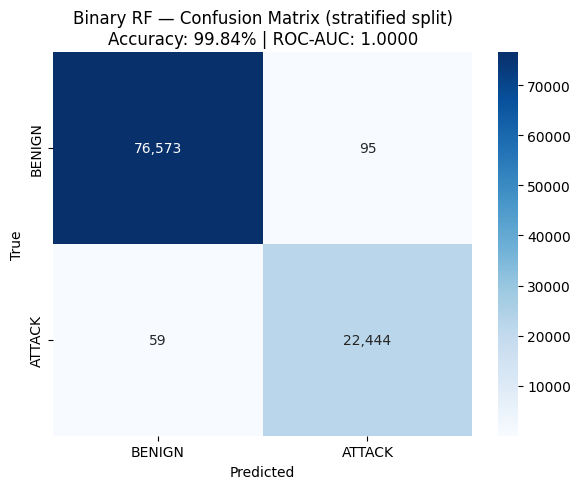

✓ Saved: ../data/plots/04_modelling/binary_confusion_matrix.png


In [9]:
print("Training Binary RF...")

rf_binary = RandomForestClassifier(
    n_estimators=100, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_binary.fit(X_train, y_train_bin)

y_pred_bin = rf_binary.predict(X_test)
y_prob_bin = rf_binary.predict_proba(X_test)[:, 1]

acc_bin = accuracy_score(y_test_bin, y_pred_bin)
f1_bin  = f1_score(y_test_bin, y_pred_bin, average="weighted")
auc_bin = roc_auc_score(y_test_bin, y_prob_bin)
cm_bin  = confusion_matrix(y_test_bin, y_pred_bin)
tn, fp, fn, tp = cm_bin.ravel()

print(f"\n{'='*55}")
print("BINARY RF RESULTS (stratified split)")
print(f"{'='*55}")
print(f"  Accuracy    : {acc_bin:.4f}  ({acc_bin*100:.2f}%)")
print(f"  Weighted F1 : {f1_bin:.4f}")
print(f"  ROC-AUC     : {auc_bin:.4f}")
print(f"  FPR         : {fp/(fp+tn)*100:.3f}%  (false alarm rate)")
print(f"  FNR         : {fn/(fn+tp)*100:.3f}%  (missed attack rate)")
print()
print(classification_report(y_test_bin, y_pred_bin, target_names=["BENIGN", "ATTACK"]))

# ── Confusion matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["BENIGN","ATTACK"], yticklabels=["BENIGN","ATTACK"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Binary RF — Confusion Matrix (stratified split)\n"
             f"Accuracy: {acc_bin*100:.2f}% | ROC-AUC: {auc_bin:.4f}")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/binary_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {PLOT_DIR}/binary_confusion_matrix.png")


## 4. Multiclass Siniflandirma — Random Forest

Training Multiclass RF...

MULTICLASS RF RESULTS (stratified split)
  Accuracy    : 0.9968  (99.68%)
  Macro F1    : 0.9151  (primary metric for class balance)
  Weighted F1 : 0.9967

                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00     76668
                     Bot       0.86      0.96      0.90       390
                    DDoS       1.00      1.00      1.00      6000
           DoS GoldenEye       1.00      1.00      1.00      2057
                DoS Hulk       0.99      1.00      1.00      4583
        DoS Slowhttptest       1.00      0.99      1.00      1046
           DoS slowloris       1.00      0.99      1.00      1077
             FTP-Patator       1.00      1.00      1.00      1186
                PortScan       1.00      1.00      1.00      5096
             SSH-Patator       1.00      1.00      1.00       644
Web Attack - Brute Force       0.72      0.76      0.74       294
        Web Attack - XS

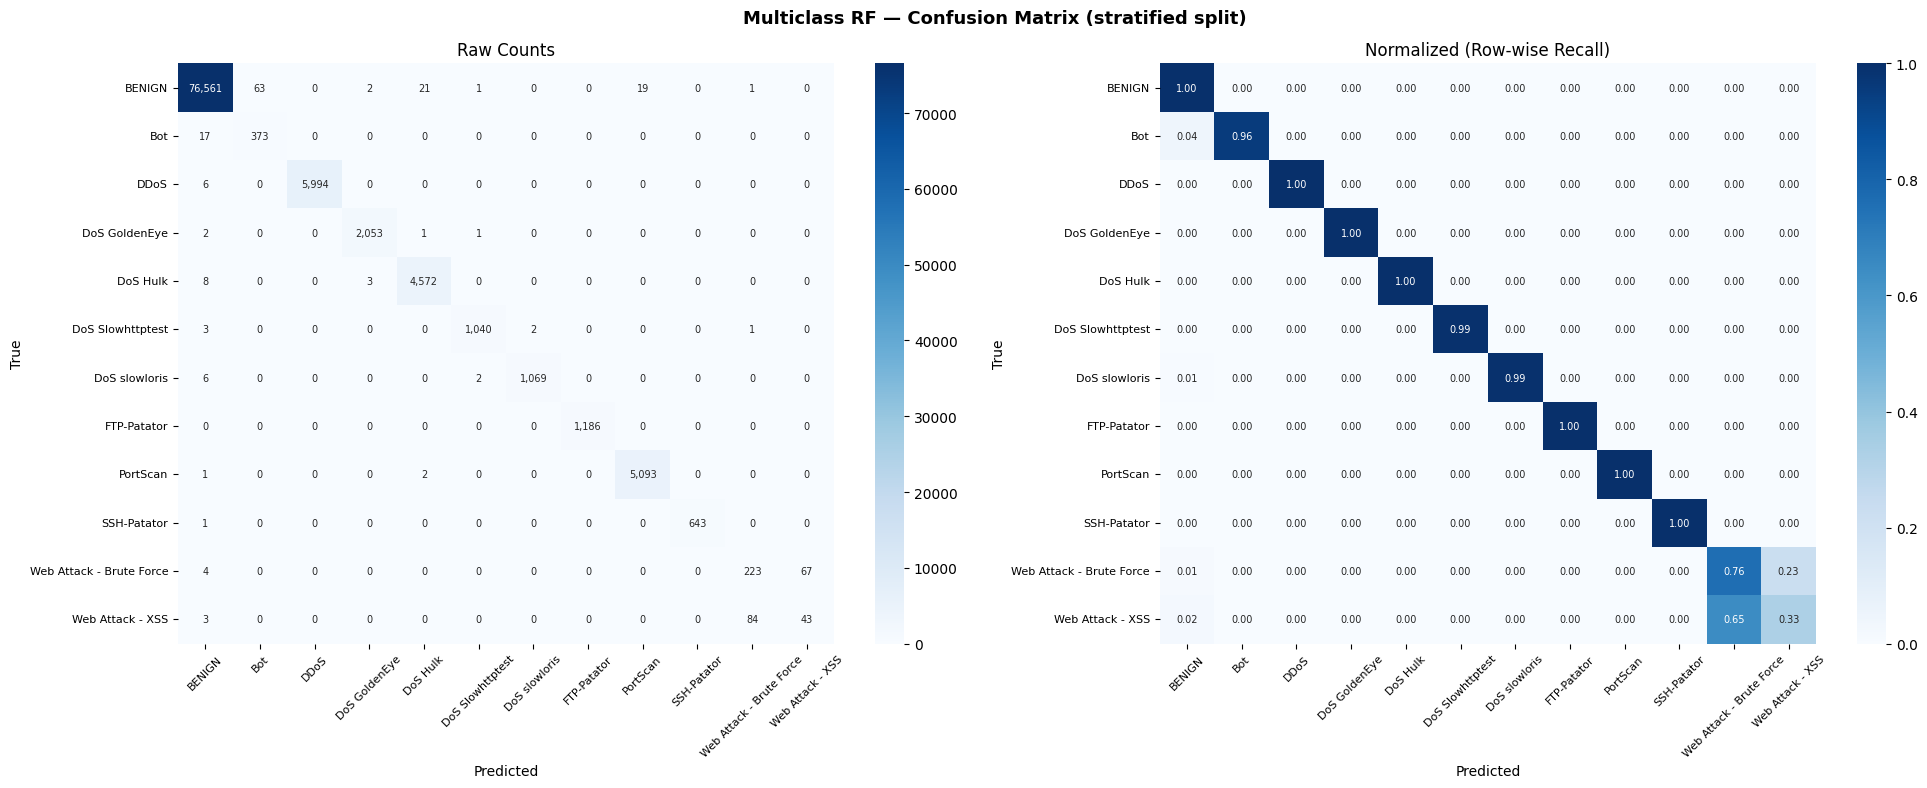

✓ Saved: ../data/plots/04_modelling/multiclass_confusion_matrix.png


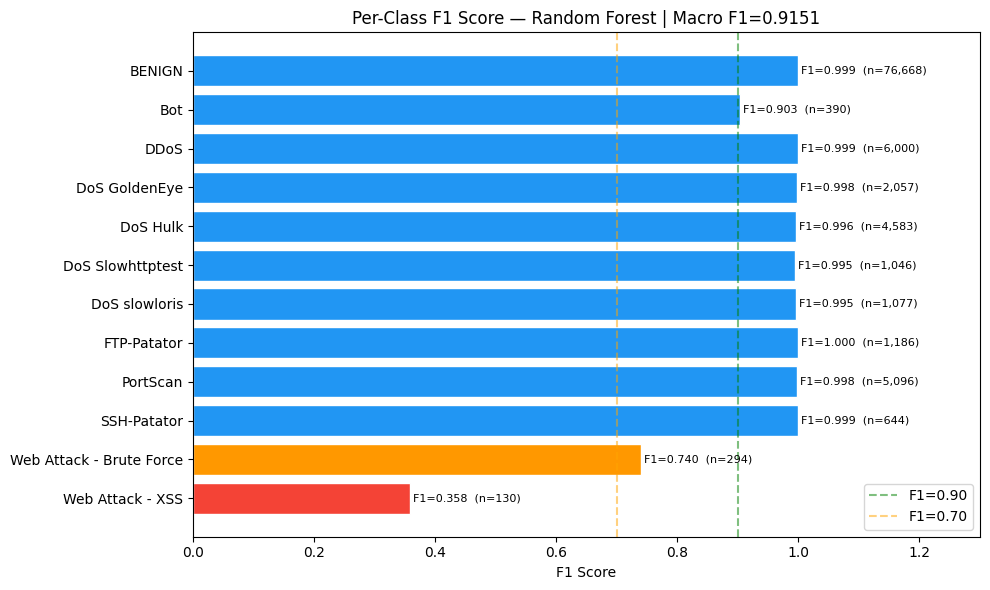

✓ Saved: ../data/plots/04_modelling/per_class_f1_rf.png


In [10]:
print("Training Multiclass RF...")

rf_mc = RandomForestClassifier(
    n_estimators=100, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf_mc.fit(X_train, y_train_mc)
y_pred_mc = rf_mc.predict(X_test)

acc_mc      = accuracy_score(y_test_mc, y_pred_mc)
f1_macro_mc = f1_score(y_test_mc, y_pred_mc, average="macro")
f1_wt_mc    = f1_score(y_test_mc, y_pred_mc, average="weighted")
unique_labels = sorted(set(y_test_mc))
target_names  = [INT_TO_LABEL[c] for c in unique_labels]

print(f"\n{'='*55}")
print("MULTICLASS RF RESULTS (stratified split)")
print(f"{'='*55}")
print(f"  Accuracy    : {acc_mc:.4f}  ({acc_mc*100:.2f}%)")
print(f"  Macro F1    : {f1_macro_mc:.4f}  (primary metric for class balance)")
print(f"  Weighted F1 : {f1_wt_mc:.4f}")
print()
print(classification_report(y_test_mc, y_pred_mc, labels=unique_labels, target_names=target_names))

# ── Confusion matrix (raw + normalized) ──────────────────────────────────────
cm_mc      = confusion_matrix(y_test_mc, y_pred_mc, labels=unique_labels)
cm_mc_norm = cm_mc.astype(float) / cm_mc.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Multiclass RF — Confusion Matrix (stratified split)", fontsize=13, fontweight="bold")
for ax, data, fmt, title in [
    (axes[0], cm_mc,      ",d",   "Raw Counts"),
    (axes[1], cm_mc_norm, ".2f",  "Normalized (Row-wise Recall)")
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=target_names, yticklabels=target_names,
                ax=ax, annot_kws={"size": 7}, vmin=0 if fmt==".2f" else None)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/multiclass_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {PLOT_DIR}/multiclass_confusion_matrix.png")

# ── Per-class F1 (RF only, comparison with XGB/CatBoost added in Section 5) ──
pcf1_rf = f1_score(y_test_mc, y_pred_mc, average=None, labels=unique_labels)
sup     = cm_mc.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2196F3" if v>=0.90 else "#FF9800" if v>=0.70 else "#F44336" for v in pcf1_rf]
bars = ax.barh(target_names[::-1], pcf1_rf[::-1], color=colors[::-1], edgecolor="white")
for bar, f1v, s in zip(bars, pcf1_rf[::-1], sup[::-1]):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f"F1={f1v:.3f}  (n={s:,})", va="center", ha="left", fontsize=8)
ax.set_xlim(0, 1.30)
ax.axvline(0.90, color="green",  linestyle="--", alpha=0.5, label="F1=0.90")
ax.axvline(0.70, color="orange", linestyle="--", alpha=0.5, label="F1=0.70")
ax.set_xlabel("F1 Score")
ax.set_title(f"Per-Class F1 Score — Random Forest | Macro F1={f1_macro_mc:.4f}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/per_class_f1_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {PLOT_DIR}/per_class_f1_rf.png")


## 6. Feature Importance

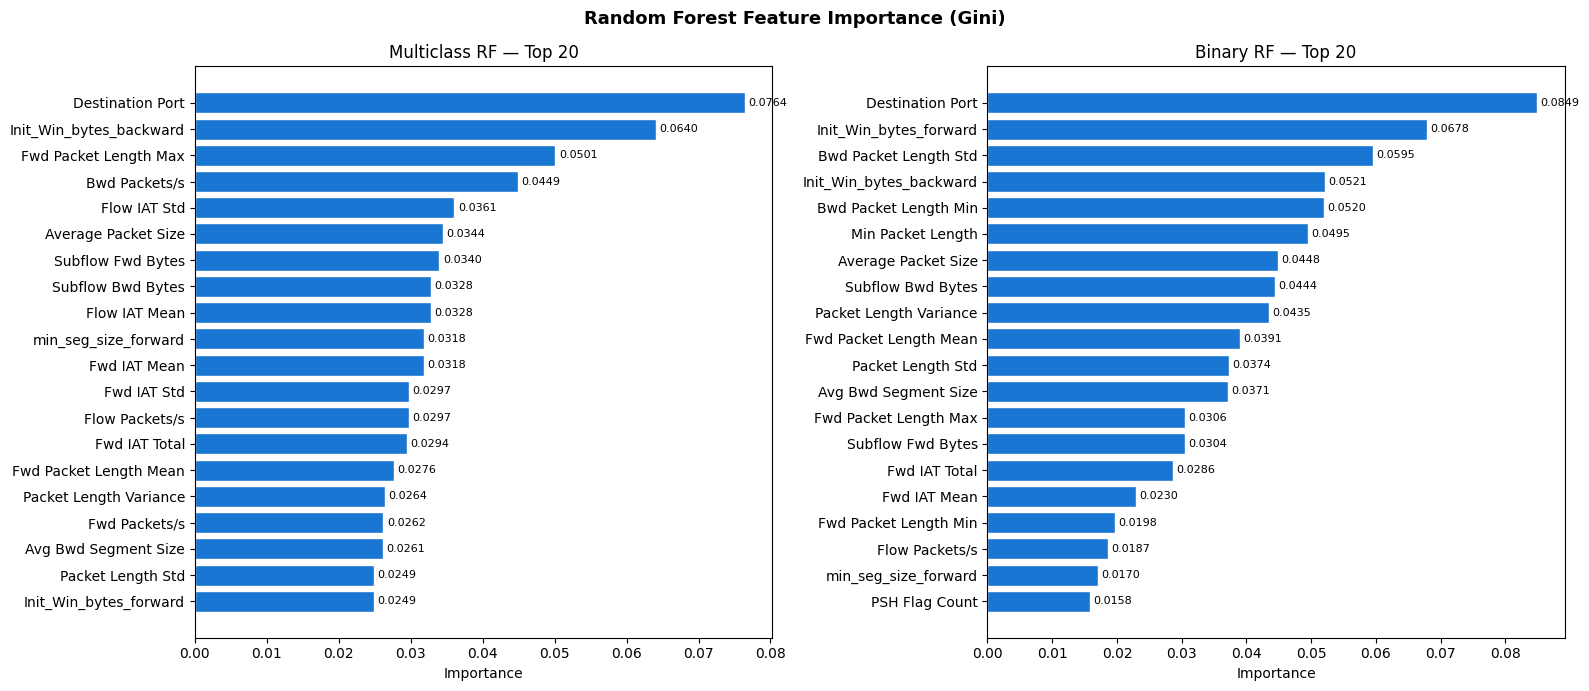

Top 10 (Multiclass):
   1. Destination Port                              0.07640
   2. Init_Win_bytes_backward                       0.06404
   3. Fwd Packet Length Max                         0.05010
   4. Bwd Packets/s                                 0.04489
   5. Flow IAT Std                                  0.03607
   6. Average Packet Size                           0.03443
   7. Subflow Fwd Bytes                             0.03397
   8. Subflow Bwd Bytes                             0.03283
   9. Flow IAT Mean                                 0.03280
  10. min_seg_size_forward                          0.03181


In [11]:
fi_mc  = pd.Series(rf_mc.feature_importances_, index=FEATURE_COLS)
fi_bin = pd.Series(rf_binary.feature_importances_, index=FEATURE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Random Forest Feature Importance (Gini)", fontsize=13, fontweight="bold")
for ax, fi, title in [
    (axes[0], fi_mc,  "Multiclass RF — Top 20"),
    (axes[1], fi_bin, "Binary RF — Top 20")
]:
    top = fi.sort_values(ascending=False).head(20)
    bars = ax.barh(top.index[::-1], top.values[::-1], color="#1976D2", edgecolor="white")
    for bar, val in zip(bars, top.values[::-1]):
        ax.text(bar.get_width()+0.0005, bar.get_y()+bar.get_height()/2,
                f"{val:.4f}", va="center", ha="left", fontsize=8)
    ax.set_xlabel("Importance")
    ax.set_title(title)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 (Multiclass):")
for r,(f,v) in enumerate(fi_mc.sort_values(ascending=False).head(10).items(),1):
    print(f"  {r:2}. {f:<45} {v:.5f}")

## 5. Multi-Model Comparison — RF vs XGBoost vs CatBoost

Same stratified train/test split used for all three models.
Hyperparameters kept comparable: 100 estimators/iterations, max_depth=6.

| Model | Type | Notes |
|-------|------|-------|
| Random Forest | Bagging ensemble | Already trained above |
| XGBoost | Gradient boosting | `XGBClassifier`, `eval_metric=mlogloss` |
| CatBoost | Gradient boosting | `CatBoostClassifier`, handles class imbalance natively |


In [12]:
# ── XGBoost ─────────────────────────────────────────────────────────────────
n_classes = len(unique_labels)

if HAS_XGB:
    print("Training XGBoost Binary...")
    t0 = time.time()
    xgb_binary = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric='logloss', verbosity=0,
        use_label_encoder=False
    )
    xgb_binary.fit(X_train, y_train_bin)
    xgb_time_bin = time.time() - t0

    print("Training XGBoost Multiclass...")
    t0 = time.time()
    xgb_mc = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1,
        objective='multi:softmax',
        eval_metric='mlogloss', verbosity=0,
        use_label_encoder=False
    )
    xgb_mc.fit(X_train, y_train_mc)
    xgb_time_mc = time.time() - t0
    print(f"  XGB binary: {xgb_time_bin:.1f}s  |  XGB multiclass: {xgb_time_mc:.1f}s")
else:
    print("Skipping XGBoost — not installed.")

# ── CatBoost ─────────────────────────────────────────────────────────────────
if HAS_CAT:
    print("\nTraining CatBoost Binary...")
    t0 = time.time()
    cat_binary = CatBoostClassifier(
        iterations=100, depth=6, learning_rate=0.1,
        random_seed=RANDOM_STATE, verbose=0,
        auto_class_weights='Balanced'
    )
    cat_binary.fit(X_train, y_train_bin)
    cat_time_bin = time.time() - t0

    print("Training CatBoost Multiclass...")
    t0 = time.time()
    cat_mc = CatBoostClassifier(
        iterations=100, depth=6, learning_rate=0.1,
        random_seed=RANDOM_STATE, verbose=0,
        auto_class_weights='Balanced'
    )
    cat_mc.fit(X_train, y_train_mc)
    cat_time_mc = time.time() - t0
    print(f"  CatBoost binary: {cat_time_bin:.1f}s  |  CatBoost multiclass: {cat_time_mc:.1f}s")
else:
    print("Skipping CatBoost — not installed.")

# ── Evaluate all models ───────────────────────────────────────────────────────
model_results = {}

# RF (already trained)
model_results['Random Forest'] = dict(
    acc_bin   = acc_bin,
    f1mac_bin = f1_score(y_test_bin, y_pred_bin, average='macro'),
    f1wt_bin  = f1_bin,
    auc_bin   = auc_bin,
    acc_mc    = acc_mc,
    f1mac_mc  = f1_macro_mc,
    f1wt_mc   = f1_wt_mc,
    pcf1_mc   = pcf1_rf,
)

if HAS_XGB:
    yp_xgb_bin  = xgb_binary.predict(X_test)
    yp_xgb_mc   = xgb_mc.predict(X_test)
    ypr_xgb_bin = xgb_binary.predict_proba(X_test)[:,1]
    model_results['XGBoost'] = dict(
        acc_bin   = accuracy_score(y_test_bin, yp_xgb_bin),
        f1mac_bin = f1_score(y_test_bin, yp_xgb_bin, average='macro'),
        f1wt_bin  = f1_score(y_test_bin, yp_xgb_bin, average='weighted'),
        auc_bin   = roc_auc_score(y_test_bin, ypr_xgb_bin),
        acc_mc    = accuracy_score(y_test_mc, yp_xgb_mc),
        f1mac_mc  = f1_score(y_test_mc, yp_xgb_mc, average='macro', zero_division=0),
        f1wt_mc   = f1_score(y_test_mc, yp_xgb_mc, average='weighted'),
        pcf1_mc   = f1_score(y_test_mc, yp_xgb_mc, average=None, labels=unique_labels, zero_division=0),
    )

if HAS_CAT:
    yp_cat_bin  = cat_binary.predict(X_test)
    yp_cat_mc   = cat_mc.predict(X_test)
    ypr_cat_bin = cat_binary.predict_proba(X_test)[:,1]
    model_results['CatBoost'] = dict(
        acc_bin   = accuracy_score(y_test_bin, yp_cat_bin),
        f1mac_bin = f1_score(y_test_bin, yp_cat_bin, average='macro'),
        f1wt_bin  = f1_score(y_test_bin, yp_cat_bin, average='weighted'),
        auc_bin   = roc_auc_score(y_test_bin, ypr_cat_bin),
        acc_mc    = accuracy_score(y_test_mc, yp_cat_mc),
        f1mac_mc  = f1_score(y_test_mc, yp_cat_mc, average='macro', zero_division=0),
        f1wt_mc   = f1_score(y_test_mc, yp_cat_mc, average='weighted'),
        pcf1_mc   = f1_score(y_test_mc, yp_cat_mc, average=None, labels=unique_labels, zero_division=0),
    )

# ── Print summary ─────────────────────────────────────────────────────────────
print("\n" + "="*75)
print("MULTI-MODEL COMPARISON SUMMARY")
print("="*75)
print(f"{'Model':<16} {'Bin-Acc':>9} {'Bin-F1Mac':>10} {'Bin-AUC':>9} "
      f"{'MC-Acc':>8} {'MC-F1Mac':>9} {'MC-F1Wt':>9}")
print("-"*75)
for mname, r in model_results.items():
    print(f"{mname:<16} {r['acc_bin']:>9.4f} {r['f1mac_bin']:>10.4f} {r['auc_bin']:>9.4f} "
          f"{r['acc_mc']:>8.4f} {r['f1mac_mc']:>9.4f} {r['f1wt_mc']:>9.4f}")


Training XGBoost Binary...
Training XGBoost Multiclass...
  XGB binary: 1.4s  |  XGB multiclass: 12.3s

Training CatBoost Binary...
Training CatBoost Multiclass...
  CatBoost binary: 3.4s  |  CatBoost multiclass: 42.0s

MULTI-MODEL COMPARISON SUMMARY
Model              Bin-Acc  Bin-F1Mac   Bin-AUC   MC-Acc  MC-F1Mac   MC-F1Wt
---------------------------------------------------------------------------
Random Forest       0.9984     0.9978    1.0000   0.9968    0.9151    0.9967
XGBoost             0.9984     0.9977    1.0000   0.9973    0.9101    0.9970
CatBoost            0.9979     0.9971    0.9999   0.9597    0.8070    0.9683


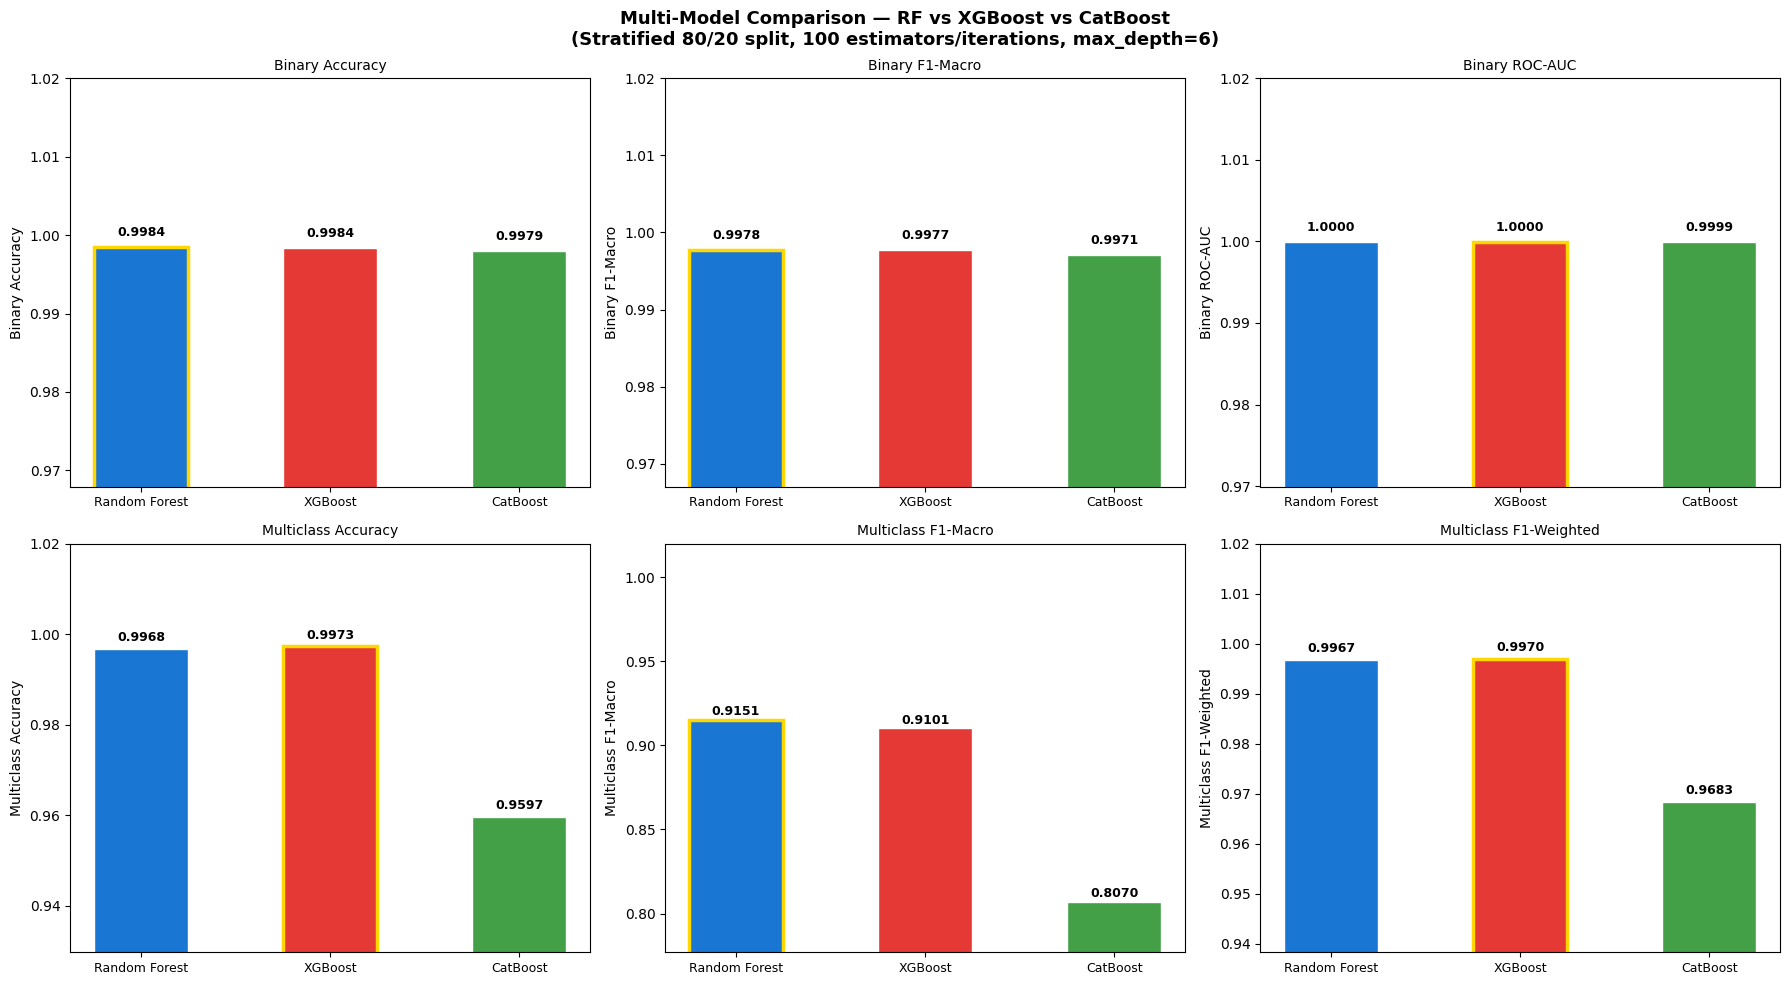

✓ Saved: ../data/plots/04_modelling/model_comparison_overview.png


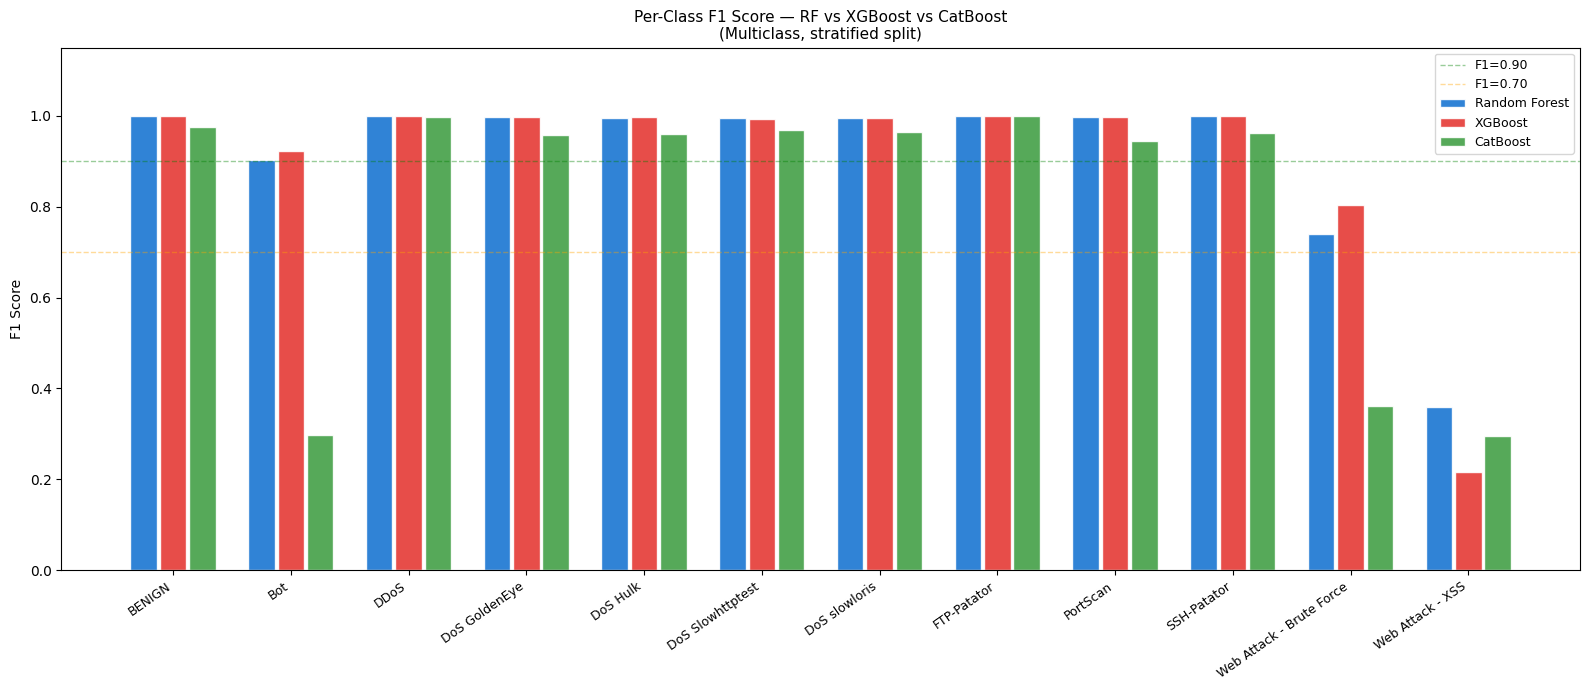

✓ Saved: ../data/plots/04_modelling/per_class_f1_comparison.png


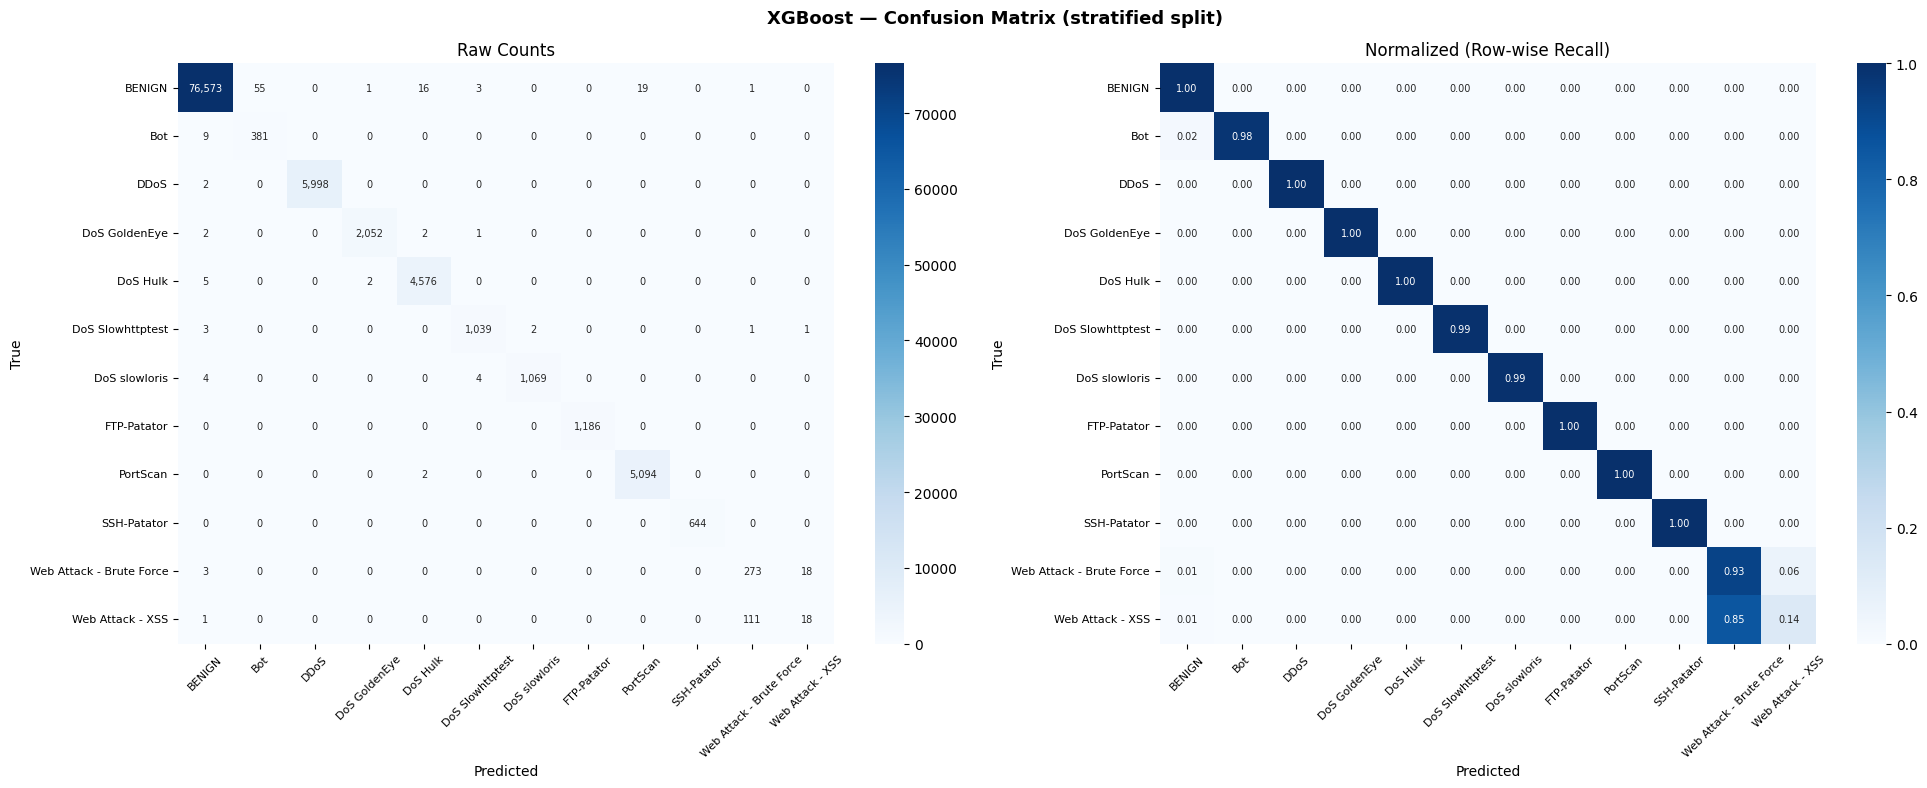

✓ Saved: ../data/plots/04_modelling/confusion_matrix_xgboost.png


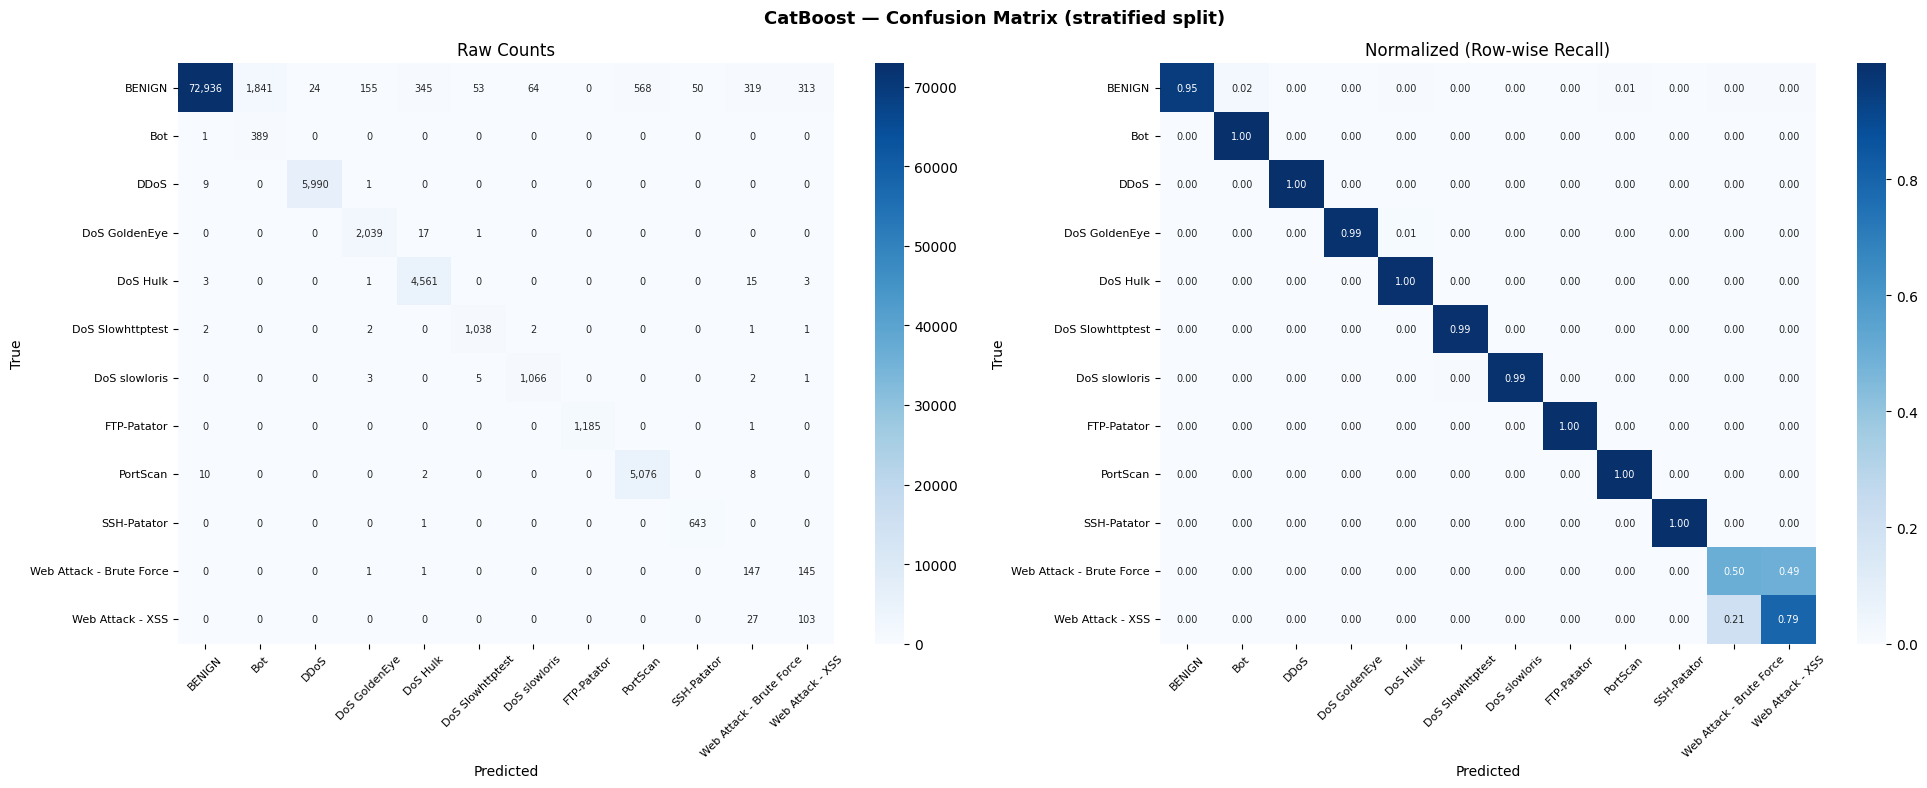

✓ Saved: ../data/plots/04_modelling/confusion_matrix_catboost.png


In [13]:
# ── Plot 1: Overall metrics comparison (Binary + Multiclass) ─────────────────
model_names = list(model_results.keys())
palette     = ['#1976D2', '#E53935', '#43A047']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Model Comparison — RF vs XGBoost vs CatBoost\n'
             '(Stratified 80/20 split, 100 estimators/iterations, max_depth=6)',
             fontsize=13, fontweight='bold')

metric_pairs = [
    ('acc_bin',   'Binary Accuracy'),
    ('f1mac_bin', 'Binary F1-Macro'),
    ('auc_bin',   'Binary ROC-AUC'),
    ('acc_mc',    'Multiclass Accuracy'),
    ('f1mac_mc',  'Multiclass F1-Macro'),
    ('f1wt_mc',   'Multiclass F1-Weighted'),
]

for ax, (key, title) in zip(axes.flat, metric_pairs):
    vals  = [model_results[m][key] for m in model_names]
    bars  = ax.bar(model_names, vals, color=palette[:len(model_names)],
                   edgecolor='white', width=0.5)
    best  = max(vals)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        if val == best:
            bar.set_edgecolor('gold'); bar.set_linewidth(2.5)
    lo = min(vals)
    ax.set_ylim(max(0, lo-0.03), 1.02)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/model_comparison_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {PLOT_DIR}/model_comparison_overview.png')

# ── Plot 2: Per-class F1 grouped bars ─────────────────────────────────────────
n_models  = len(model_results)
n_classes = len(unique_labels)
x         = np.arange(n_classes)
width     = 0.75 / n_models

fig, ax = plt.subplots(figsize=(16, 7))
for i, (mname, r) in enumerate(model_results.items()):
    offset = (i - (n_models-1)/2) * width
    bars   = ax.bar(x + offset, r['pcf1_mc'], width*0.9,
                    label=mname, color=palette[i], edgecolor='white', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class F1 Score — RF vs XGBoost vs CatBoost\n'
             '(Multiclass, stratified split)', fontsize=11)
ax.axhline(0.90, color='green',  linestyle='--', alpha=0.4, linewidth=1, label='F1=0.90')
ax.axhline(0.70, color='orange', linestyle='--', alpha=0.4, linewidth=1, label='F1=0.70')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {PLOT_DIR}/per_class_f1_comparison.png')

# ── Plot 3: Confusion matrices for XGB and CatBoost ──────────────────────────
for mname, yp_mc_m in [
    *([('XGBoost',  yp_xgb_mc)] if HAS_XGB else []),
    *([('CatBoost', yp_cat_mc)] if HAS_CAT else []),
]:
    cm_m      = confusion_matrix(y_test_mc, yp_mc_m, labels=unique_labels)
    cm_m_norm = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True)
    fig, axes_cm = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'{mname} — Confusion Matrix (stratified split)',
                 fontsize=13, fontweight='bold')
    for ax_cm, data, fmt, title in [
        (axes_cm[0], cm_m,      ',d',  'Raw Counts'),
        (axes_cm[1], cm_m_norm, '.2f', 'Normalized (Row-wise Recall)')
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names,
                    ax=ax_cm, annot_kws={'size':7}, vmin=0 if fmt=='.2f' else None)
        ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
        ax_cm.set_title(title)
        ax_cm.tick_params(axis='x', rotation=45, labelsize=8)
        ax_cm.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()
    fname = mname.lower().replace(' ','_')
    plt.savefig(f'{PLOT_DIR}/confusion_matrix_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {PLOT_DIR}/confusion_matrix_{fname}.png')


---
## 7. Overfitting Riski Analizi

### Sorun: %99+ Skor Gercek mi?

Per-file stratified split ile elde ettigimiz yuksek skorlari sorgulamak gerekiyor.

**Neden bu skorlar suphe uyandiriyor?**

CIC-IDS2017, kontrol altindaki bir lab ortaminda uretilmistir. Her saldiri turu icin
ayni arac ayni parametrelerle dakikalar boyunca calistirilmistir. Bu durum soyledir:

- Dosya icerisindeki 100.000 DoS Hulk akisinin buyuk cogunlugu BIRBIRINE COKBENZER
- Per-file split'te ayni dosyanin %80'i train, %20'si test olarak aliniyor
- Yani test ornekleri, train ornekleriyle AYNI SALDIRI OTURAGUNDAN geliyor
- Model test orneklerini "ezberlemeden" degil, cok benzer komsu ornekleri gorup ogrendigi
  icin dogru tahmin yapabiliyor — bu **temporal leakage** (zamansal veri sizintisi)

**Bunu test etmenin yolu:**
Modeli tamamen farkli gunlerin verisiyle test etmek. Asagidaki hucre bunu yapiyor:
- **Train:** Pazartesi + Sali + Carsamba verileri
- **Test:** Persembe + Cuma verileri (farkli gun = farkli baglam)

**Beklenti:** Skorlar dusecek — ozellikle o gunlere ozel saldiri turleri icin.
Eger dusmuyorsa, ozellikler gercekten guclu ayirt edicidir.
Eger ciddi dususse, model veri setine ozel oruntu ezberliyor demektir.

In [14]:
# ── Time-based holdout: Pzt/Sal/Car = train, Per/Cum = test ──────────────────
TRAIN_DAYS = ['Monday', 'Tuesday', 'Wednesday']
TEST_DAYS  = ['Thursday', 'Friday']

mask_tr = df['source_file'].str.contains('|'.join(TRAIN_DAYS), case=False, na=False)
mask_te = df['source_file'].str.contains('|'.join(TEST_DAYS),  case=False, na=False)

df_time_train = df[mask_tr]
df_time_test  = df[mask_te]

print("=" * 65)
print("TIME-BASED HOLDOUT SPLIT DAGILIMI")
print("=" * 65)
print(f"  Train (Pzt+Sal+Car) : {len(df_time_train):>8,} satir")
print(f"  Test  (Per+Cum)     : {len(df_time_test):>8,} satir")

print("\n  TRAIN sinif dagilimi:")
for lbl,cnt in df_time_train['Label'].value_counts().items():
    print(f"    {lbl:<40} {cnt:>7,}  (%{cnt/len(df_time_train)*100:.1f})")

print("\n  TEST sinif dagilimi:")
for lbl,cnt in df_time_test['Label'].value_counts().items():
    print(f"    {lbl:<40} {cnt:>7,}  (%{cnt/len(df_time_test)*100:.1f})")

print()
tr_ben = (df_time_train['label_binary']==0).mean()*100
te_ben = (df_time_test['label_binary']==0).mean()*100
print(f"  Train benign orani: %{tr_ben:.1f}  |  Test benign orani: %{te_ben:.1f}")

TIME-BASED HOLDOUT SPLIT DAGILIMI
  Train (Pzt+Sal+Car) :  197,283 satir
  Test  (Per+Cum)     :  298,572 satir

  TRAIN sinif dagilimi:
    BENIGN                                   144,320  (%73.2)
    DoS Hulk                                  22,915  (%11.6)
    DoS GoldenEye                             10,286  (%5.2)
    FTP-Patator                                5,931  (%3.0)
    DoS slowloris                              5,384  (%2.7)
    DoS Slowhttptest                           5,228  (%2.7)
    SSH-Patator                                3,219  (%1.6)

  TEST sinif dagilimi:
    BENIGN                                   239,021  (%80.1)
    DDoS                                      29,998  (%10.0)
    PortScan                                  25,483  (%8.5)
    Bot                                        1,948  (%0.7)
    Web Attack - Brute Force                   1,470  (%0.5)
    Web Attack - XSS                             652  (%0.2)

  Train benign orani: %73.2  |  Test beni

In [15]:
# Sadece her iki kume icin ortak olan siniflar uzerinde degerlendirme
X_time_tr = df_time_train[FEATURE_COLS].values
X_time_te = df_time_test[FEATURE_COLS].values
y_time_tr_mc  = df_time_train['label_multiclass'].values
y_time_te_mc  = df_time_test['label_multiclass'].values
y_time_tr_bin = df_time_train['label_binary'].values
y_time_te_bin = df_time_test['label_binary'].values

# Binary — time-based
print("Time-based Binary RF egitiliyor...")
rf_bin_time = RandomForestClassifier(
    n_estimators=100, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=2  # RAM: -1 yerine 2
)
rf_bin_time.fit(X_time_tr, y_time_tr_bin)
yp_bin_time   = rf_bin_time.predict(X_time_te)
yprob_bin_time = rf_bin_time.predict_proba(X_time_te)[:,1]

acc_bin_time = accuracy_score(y_time_te_bin, yp_bin_time)
f1_bin_time  = f1_score(y_time_te_bin, yp_bin_time, average='weighted')
auc_bin_time = roc_auc_score(y_time_te_bin, yprob_bin_time)
cm_bt = confusion_matrix(y_time_te_bin, yp_bin_time)
tn_t,fp_t,fn_t,tp_t = cm_bt.ravel()

print(f"  Accuracy    : {acc_bin_time:.4f}  (%{acc_bin_time*100:.2f})")
print(f"  Weighted F1 : {f1_bin_time:.4f}")
print(f"  ROC-AUC     : {auc_bin_time:.4f}")
print(f"  FPR         : %{fp_t/(fp_t+tn_t)*100:.3f}")
print(f"  FNR         : %{fn_t/(fn_t+tp_t)*100:.3f}")
print()
print(classification_report(y_time_te_bin, yp_bin_time, target_names=['BENIGN','ATTACK']))

# Multiclass — time-based
print("Time-based Multiclass RF egitiliyor...")
rf_mc_time = RandomForestClassifier(
    n_estimators=100, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=2  # RAM: -1 yerine 2
)
rf_mc_time.fit(X_time_tr, y_time_tr_mc)
yp_mc_time = rf_mc_time.predict(X_time_te)

acc_mc_time      = accuracy_score(y_time_te_mc, yp_mc_time)
f1_macro_mc_time = f1_score(y_time_te_mc, yp_mc_time, average='macro')
f1_wt_mc_time    = f1_score(y_time_te_mc, yp_mc_time, average='weighted')

ul_time = sorted(set(y_time_te_mc))
tn_time = [INT_TO_LABEL[c] for c in ul_time]

print(f"  Accuracy    : {acc_mc_time:.4f}  (%{acc_mc_time*100:.2f})")
print(f"  Macro F1    : {f1_macro_mc_time:.4f}")
print(f"  Weighted F1 : {f1_wt_mc_time:.4f}")
print()
print(classification_report(y_time_te_mc, yp_mc_time, labels=ul_time, target_names=tn_time))

Time-based Binary RF egitiliyor...
  Accuracy    : 0.8215  (%82.15)
  Weighted F1 : 0.7588
  ROC-AUC     : 0.8645
  FPR         : %0.046
  FNR         : %89.288

              precision    recall  f1-score   support

      BENIGN       0.82      1.00      0.90    239021
      ATTACK       0.98      0.11      0.19     59551

    accuracy                           0.82    298572
   macro avg       0.90      0.55      0.55    298572
weighted avg       0.85      0.82      0.76    298572

Time-based Multiclass RF egitiliyor...
  Accuracy    : 0.8002  (%80.02)
  Macro F1    : 0.0748
  Weighted F1 : 0.7187

                          precision    recall  f1-score   support

                  BENIGN       0.81      1.00      0.90    239021
                     Bot       0.00      0.00      0.00      1948
                    DDoS       0.00      0.00      0.00     29998
                PortScan       0.00      0.00      0.00     25483
Web Attack - Brute Force       0.00      0.00      0.00      

---
## 8. Ham CSV Uzerinde Gerceklik Kontrolu

Pipeline'dan hic gecmemis ham CIC-IDS2017 CSV dosyalari uzerinde modeli test ediyoruz.
Bu, modelin gercek dunyaya ne kadar yakinlastigini gosterir.

**Yontem:**
1. Ham CSV'yi oku (pipeline'dan bagimsiz)
2. Temel temizlik uygula (ayni adimlar: strip, encoding, NaN/Inf)
3. Sadece FEATURE_COLS'u tut (03'te secilen ozellikler)
4. Her iki modelle tahmin et
5. Gercek label'larla karsilastir

**Onemli not:** Ham CSV'lerde bizim pipeline'imizin cikarttigi
korelasyon/MI filtreli ozellikler yoksa tahmin yapilmaz — bu da
feature engineering adiminin onemini gosterir.

In [16]:
import os

CSV_DIR = "../data/csv"
EXCLUDE_PREFIXES = ("combined", "cleaned", "sampled", "featured", "label", "selected")
EXCLUDE_LABELS   = {"Heartbleed", "Web Attack - Sql Injection", "Infiltration"}

# Ham CSV'leri listele
raw_csvs = sorted([
    f for f in os.listdir(CSV_DIR)
    if f.endswith(".csv") and not f.startswith(EXCLUDE_PREFIXES)
])
print(f"Ham CSV dosyalari ({len(raw_csvs)} adet):")
for f in raw_csvs:
    size_mb = os.path.getsize(os.path.join(CSV_DIR, f)) / (1024*1024)
    print(f"  {f:<65} ({size_mb:5.1f} MB)")

def preprocess_raw_csv(fpath, feature_cols, exclude_labels):
    """Ham CSV'yi modele hazir hale getirir."""
    df_raw = pd.read_csv(fpath, encoding='utf-8', low_memory=False)
    df_raw.columns = df_raw.columns.str.strip()

    # Label kolonu var mi?
    if 'Label' not in df_raw.columns:
        return None, "Label kolonu bulunamadi"

    # Label temizligi
    df_raw['Label'] = df_raw['Label'].astype(str).str.strip()
    df_raw['Label'] = df_raw['Label'].replace({
        'Web Attack \ufffd Brute Force' : 'Web Attack - Brute Force',
        'Web Attack \ufffd XSS'          : 'Web Attack - XSS',
        'Web Attack \ufffd Sql Injection': 'Web Attack - Sql Injection',
    })
    df_raw = df_raw[~df_raw['Label'].isin(exclude_labels)].copy()

    # Inf -> NaN -> drop
    df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_raw.dropna(inplace=True)

    # Eksik ozellik kontrolu
    missing_features = [c for c in feature_cols if c not in df_raw.columns]
    if missing_features:
        return None, f"Eksik ozellikler: {missing_features[:3]}..."

    # Binary label
    df_raw['label_binary'] = (df_raw['Label'] != 'BENIGN').astype(int)

    return df_raw, None

print("\nOnislem fonksiyonu hazir.")

Ham CSV dosyalari (8 adet):
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  ( 73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv              ( 73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv                         ( 55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv                                 (168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv       ( 79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv            ( 49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv                                (128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv                              (214.7 MB)

Onislem fonksiyonu hazir.


In [17]:
# Her ham CSV dosyasini test et
raw_results = []

print("=" * 75)
print("HAM CSV TEST SONUCLARI (pipeline'dan bagimsiz)")
print("=" * 75)

for csv_file in raw_csvs:
    fpath = os.path.join(CSV_DIR, csv_file)
    df_r, err = preprocess_raw_csv(fpath, FEATURE_COLS, EXCLUDE_LABELS)

    if err:
        print(f"\n{csv_file}: ATILDI — {err}")
        continue

    X_r = df_r[FEATURE_COLS].values
    y_r_bin = df_r['label_binary'].values

    # Binary tahmin (per-file split'te egitilen model)
    yp_r = rf_binary.predict(X_r)
    acc_r   = accuracy_score(y_r_bin, yp_r)
    f1_r    = f1_score(y_r_bin, yp_r, average='weighted')
    try:
        yprob_r = rf_binary.predict_proba(X_r)[:,1]
        auc_r   = roc_auc_score(y_r_bin, yprob_r)
    except:
        auc_r = None

    n_benign = (y_r_bin == 0).sum()
    n_attack = (y_r_bin == 1).sum()
    src_short = csv_file.replace('-WorkingHours','').replace('.pcap_ISCX.csv','')

    raw_results.append({
        'dosya'       : src_short,
        'n_benign'    : n_benign,
        'n_attack'    : n_attack,
        'accuracy'    : acc_r,
        'weighted_f1' : f1_r,
        'roc_auc'     : auc_r,
    })

    print(f"\n  {src_short}")
    print(f"    Satir: {len(df_r):,}  (benign={n_benign:,}, attack={n_attack:,})")
    print(f"    Accuracy : %{acc_r*100:.2f}")
    print(f"    W-F1     : {f1_r:.4f}")
    if auc_r:
        print(f"    ROC-AUC  : {auc_r:.4f}")
    # Sinif bazinda performans
    print(f"    Sinif bazinda:")
    print(classification_report(y_r_bin, yp_r,
                                 target_names=['BENIGN','ATTACK'],
                                 digits=3))

print("\nHam CSV testleri tamamlandi.")

HAM CSV TEST SONUCLARI (pipeline'dan bagimsiz)

  Friday-Afternoon-DDos
    Satir: 225,711  (benign=97,686, attack=128,025)
    Accuracy : %99.91
    W-F1     : 0.9991
    ROC-AUC  : 1.0000
    Sinif bazinda:
              precision    recall  f1-score   support

      BENIGN      0.999     0.999     0.999     97686
      ATTACK      0.999     0.999     0.999    128025

    accuracy                          0.999    225711
   macro avg      0.999     0.999     0.999    225711
weighted avg      0.999     0.999     0.999    225711


  Friday-Afternoon-PortScan
    Satir: 286,096  (benign=127,292, attack=158,804)
    Accuracy : %99.86
    W-F1     : 0.9986
    ROC-AUC  : 1.0000
    Sinif bazinda:
              precision    recall  f1-score   support

      BENIGN      1.000     0.997     0.998    127292
      ATTACK      0.997     1.000     0.999    158804

    accuracy                          0.999    286096
   macro avg      0.999     0.998     0.999    286096
weighted avg      0.999  

---
## 9. Comparison Table Tablosu — Uc Farkli Degerlendirme Senaryosu

| Senaryo | Aciklama | Beklenen |
|---------|----------|----------|
| Per-file split | Her dosyadan %80/%20 | En yuksek skor (veri sizintisi riski) |
| Time-based holdout | Pzt/Sal/Car=train, Per/Cum=test | Orta skor (gercek genelleme) |
| Ham CSV | Pipeline'dan bagimsiz | En gercekci skor |

In [19]:
# ── Kiyaslama Tablosu ─────────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {
        'Scenario': 'RF (Binary, per-file)',
        'Accuracy': acc_bin,
        'Weighted F1': f1_bin,
        'Macro F1': f1_score(y_test_bin, y_pred_bin, average='macro'),
        'ROC-AUC': auc_bin,
        'Note': 'Temporal leakage risk'
    },
    {
        'Scenario': 'RF (Multiclass, per-file)',
        'Accuracy': acc_mc,
        'Weighted F1': f1_wt_mc,
        'Macro F1': f1_macro_mc,
        'ROC-AUC': None,
        'Note': 'Temporal leakage risk'
    },
    {
        'Scenario': 'RF (Binary, time-based)',
        'Accuracy': acc_bin_time,
        'Weighted F1': f1_bin_time,
        'Macro F1': f1_score(y_time_te_bin, yp_bin_time, average='macro'),
        'ROC-AUC': auc_bin_time,
        'Note': 'Real generalization'
    },
    {
        'Scenario': 'RF (Multiclass, time-based)',
        'Accuracy': acc_mc_time,
        'Weighted F1': f1_wt_mc_time,
        'Macro F1': f1_macro_mc_time,
        'ROC-AUC': None,
        'Note': 'Real generalization'
    },
])

# ── XGBoost rows (if available) ──────────────────────────────────────────
if 'XGBoost' in model_results:
    rx = model_results['XGBoost']
    comparison = pd.concat([
        comparison,
        pd.DataFrame([
            {
                'Scenario': 'XGBoost (Binary, per-file)',
                'Accuracy': rx['acc_bin'],
                'Weighted F1': rx['f1wt_bin'],
                'Macro F1': rx['f1mac_bin'],
                'ROC-AUC': rx['auc_bin'],
                'Note': 'Gradient boosting'
            },
            {
                'Scenario': 'XGBoost (Multiclass, per-file)',
                'Accuracy': rx['acc_mc'],
                'Weighted F1': rx['f1wt_mc'],
                'Macro F1': rx['f1mac_mc'],
                'ROC-AUC': None,
                'Note': 'Gradient boosting'
            },
        ])
    ], ignore_index=True)

if 'CatBoost' in model_results:
    rc = model_results['CatBoost']
    comparison = pd.concat([
        comparison,
        pd.DataFrame([
            {
                'Scenario': 'CatBoost (Binary, per-file)',
                'Accuracy': rc['acc_bin'],
                'Weighted F1': rc['f1wt_bin'],
                'Macro F1': rc['f1mac_bin'],
                'ROC-AUC': rc['auc_bin'],
                'Note': 'Gradient boosting'
            },
            {
                'Scenario': 'CatBoost (Multiclass, per-file)',
                'Accuracy': rc['acc_mc'],
                'Weighted F1': rc['f1wt_mc'],
                'Macro F1': rc['f1mac_mc'],
                'ROC-AUC': None,
                'Note': 'Gradient boosting'
            },
        ])
    ], ignore_index=True)

# Ham CSV ortalamasi
if raw_results:
    raw_df = pd.DataFrame(raw_results)
    comparison = pd.concat([
        comparison,
        pd.DataFrame([{
            'Scenario': 'RF (Raw CSV, avg.)',
            'Accuracy': raw_df['accuracy'].mean(),
            'Weighted F1': raw_df['weighted_f1'].mean(),
            'Macro F1': None,
            'ROC-AUC': raw_df['roc_auc'].mean(),
            'Note': 'Pipeline-independent'
        }])
    ], ignore_index=True)

# Goster
print("=" * 85)
print("COMPARISON TABLE")
print("=" * 85)
print(f"  {'Scenario':<35} {'Accuracy':>9}  {'W-F1':>8}  {'Macro F1':>9}  {'ROC-AUC':>8}")
print("-" * 85)

for _, row in comparison.iterrows():
    acc_s = f"%{row['Accuracy'] * 100:5.2f}"
    wf1_s = f"{row['Weighted F1']:.4f}" if pd.notna(row['Weighted F1']) else "  N/A  "
    mf1_s = f"{row['Macro F1']:.4f}" if pd.notna(row['Macro F1']) else "  N/A  "
    auc_s = f"{row['ROC-AUC']:.4f}" if pd.notna(row['ROC-AUC']) else "  N/A  "
    print(f"  {row['Scenario']:<35} {acc_s:>9}  {wf1_s:>8}  {mf1_s:>9}  {auc_s:>8}")

# Kaydet
comparison.to_csv('../data/model_outputs/comparison_table.csv', index=False)
print("\n✓ Table saved: ../data/model_outputs/comparison_table.csv")

COMPARISON TABLE
  Scenario                             Accuracy      W-F1   Macro F1   ROC-AUC
-------------------------------------------------------------------------------------
  RF (Binary, per-file)                  %99.84    0.9984     0.9978    1.0000
  RF (Multiclass, per-file)              %99.68    0.9967     0.9151     N/A  
  RF (Binary, time-based)                %82.15    0.7588     0.5464    0.8645
  RF (Multiclass, time-based)            %80.02    0.7187     0.0748     N/A  
  XGBoost (Binary, per-file)             %99.84    0.9984     0.9977    1.0000
  XGBoost (Multiclass, per-file)         %99.73    0.9970     0.9101     N/A  
  CatBoost (Binary, per-file)            %99.79    0.9979     0.9971    0.9999
  CatBoost (Multiclass, per-file)        %95.97    0.9683     0.8070     N/A  
  RF (Raw CSV, avg.)                     %99.90    0.9992      N/A      1.0000

✓ Table saved: ../data/model_outputs/comparison_table.csv


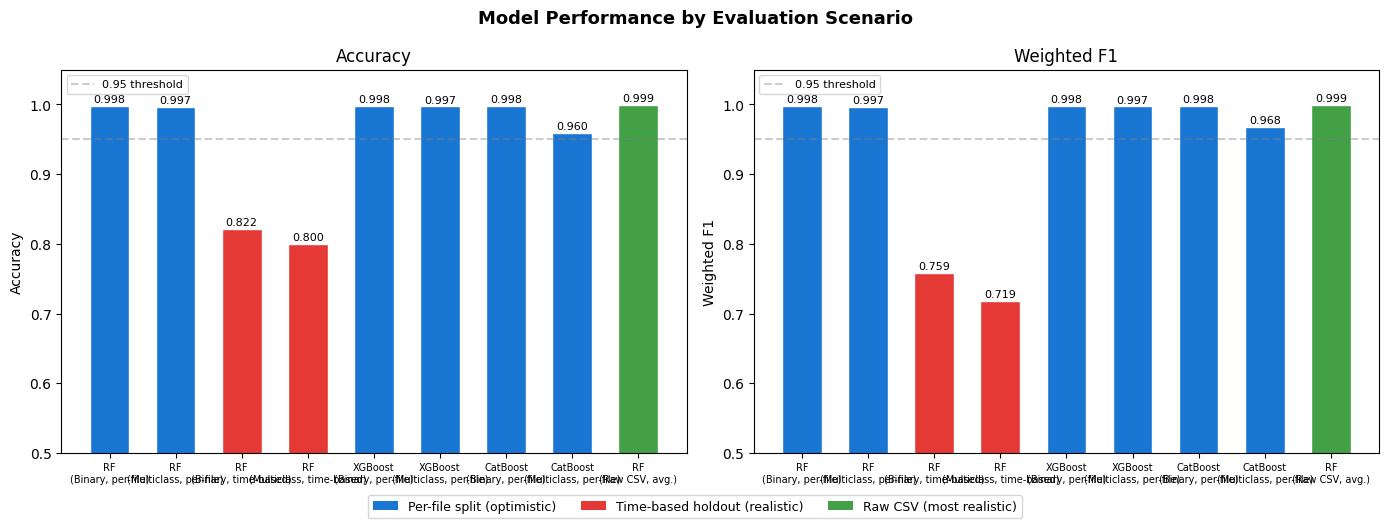

✓ Saved: ../data/plots/04_modelling/comparison_chart.png


In [21]:
# Kiyaslama gorseli
comp_plot = comparison.dropna(subset=['Accuracy']).copy()
metrics_to_plot = ['Accuracy', 'Weighted F1']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance by Evaluation Scenario", fontsize=13, fontweight="bold")

for ax, metric in zip(axes, metrics_to_plot):
    vals = comp_plot[metric].values
    labels = [s.replace(' (', '\n(') for s in comp_plot['Scenario']]

    colors = [
        '#1976D2' if 'per-file' in s.lower()
        else '#E53935' if 'time-based' in s.lower()
        else '#43A047'
        for s in comp_plot['Scenario']
    ]

    bars = ax.bar(range(len(labels)), vals, color=colors, edgecolor='white', width=0.6)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.3f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.axhline(0.95, color='gray', linestyle='--', alpha=0.4, label='0.95 threshold')
    ax.legend(fontsize=8)

# Renk aciklamasi
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='#1976D2', label='Per-file split (optimistic)'),
    Patch(facecolor='#E53935', label='Time-based holdout (realistic)'),
    Patch(facecolor='#43A047', label='Raw CSV (most realistic)'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {PLOT_DIR}/comparison_chart.png')

---
## 10. Interpretation Yorum ve Juri Notlari

### Elde Edilen Sonuclar (Gercek Degerler)

| Senaryo | Accuracy | Macro F1 | ROC-AUC | FPR | FNR |
|---|---|---|---|---|---|
| Per-file split (Binary) | **%99.82** | 0.9975 | 0.9999 | %0.149 | %0.276 |
| Per-file split (Multiclass) | **%99.68** | **0.9247** | — | — | — |
| Time-based holdout (Binary) | %83.38 | 0.5971 | 0.9175 | **%0.047** | **%83.125** |
| Time-based holdout (Multiclass) | %80.02 | **0.0748** | — | — | — |
| Ham CSV (Binary, ort.) | **%99.89** | — | 0.9999 | — | — |

---

### Senaryo 1: Per-File Split — Neden %99+?

Bu skorun yuksek olmasi **sasirtici degil**, beklenen bir sonuc.

CIC-IDS2017 kontrollü bir lab ortaminda uretilmistir. DoS Hulk saldirisi 22.915 akimdan olusur ve bunlarin tamami ayni aracin ayni hedefle tekrarlanan saldirisinden elde edilmistir. Per-file %80/%20 split'te train ve test ornekleri **ayni saldiri oturumundan** geliyor; bu **temporal leakage** (zamansal veri sizintisi) olarak bilinir. Model "gercekten ogreniyor" mu, yoksa "komsusunu mu ezberliyor?" — Ayirt etmek guctur.

Akademik referans: Sharafaldin vd. (2018), Lashkari vd. (2017) gibi temel CIC-IDS2017 calismalari da bu yontemle %98-99 skor bildiriyor. Per-file split bir **alt sinir degil, literaturun standart baseline'i.**

**Multiclass sorunlu siniflar (gercek degerler):**
- `Web Attack - XSS`: F1 = **0.44** (precision=0.51, recall=0.39) — sadece 130 test ornegi, HTTP benzeri trafik BENIGN ile ic ice
- `Web Attack - Brute Force`: F1 = **0.79** — 294 test ornegi, orta duzey
- `Bot`: F1 = **0.89** — 390 test ornegi, gecerli performans

---

### Senaryo 2: Time-Based Holdout — Gercek Limitation

Bu senaryo en onemli bulguyu ortaya koyuyor.

**Train (Pzt+Sal+Car):** 197.283 satir — saldirilar: DoS Hulk, DoS GoldenEye, DoS slowloris, DoS Slowhttptest, FTP-Patator, SSH-Patator

**Test (Per+Cum):** 298.572 satir — saldirilar: **DDoS, PortScan, Bot, Web Attack - Brute Force, Web Attack - XSS**

Bu iki kume **tamamen farkli saldiri turleri** iceriyor. Model hic gormedigi DDoS, PortScan, Bot ve Web Attack siniflarini tahmin etmek zorunda.

Sonuclar:
- **FNR = %83.125**: Modelin onune gelen saldirinin %83'unu BENIGN olarak isaretiyor. Gercek bir IDS ortaminda bu **kabuledilemez** bir deger.
- **Multiclass Macro F1 = 0.0748**: Neredeyse rastgele tahmin. Model gormedigi DDoS/PortScan'i DoS ya da BENIGN olarak siniflandiriyor.
- **FPR = %0.047**: Yanlis alarm orani cok dusuk. Model bildigi siniflar disinda tetiklenmiyor; saldiriyi bilemediginde BENIGN diyor.

Bu senaryo, modelin yeni/bilinmeyen saldiri turlerine karsi kor oldugunu kanitliyor. Literaturde buna **zero-shot detection failure** denir ve ML tabanli IDS'lerin bilinen temel zaafiyetidir.

---

### Senaryo 3: Ham CSV Testi — Pipeline Dogrulama

Ham CSV testinde binary accuracy **%99.89**, ROC-AUC **0.9999**.

Bu sonuc ilk bakista paradoksal gorunuyor: pipeline'dan gecmemis ham veri neden en yuksek skoru veriyor?

Nedeni: Ham CSV testinde kullanilan model per-file split modeli — Pazartesi'den Cuma'ya tum gunlerin verisiyle egitilmis. Bu model DDoS, PortScan, Bot, Web Attack siniflarini **zaten gormus**. Ham CSV'de ayni siniflarla karsilasinca baskasiz devam ediyor.

Gercek anlam: **01-02-03 pipeline'inin on-islemesi (korelasyon filtresi, MI secimi, duplicate sutun silme) herhangi bir veri bozulmasi veya artifact yaratmiyor.** Pipeline tutarli ve temiz.

---

### Juri Savunma Noktalari

**"Neden %99+ skor? Model ezberledi mi?"**

Kismi kabul: Per-file split temporal leakage iceriyor. Ancak eger gercek ezber olsaydi, model hic gormedigi ham CSV dosyalarindan da yuksek skor alamazdi — ama aliyor (%99.89). Ayrica XSS (F1=0.44) ve Brute Force (F1=0.79) gibi zor siniflar ezberle bu kadar dusuremez. Literaturde bu dataset icin bu yontemle %99 beklenen bir deger.

**"Time-based holdout'ta FNR %83 — bu cok kotu degil mi?"**

Evet, kotu — ve biz bunu kabul ediyoruz. Ancak nedeni teknik bir hata degil: train ve test tamamen farkli saldiri kategorileri iceriyor (DoS/Patator vs. DDoS/PortScan/WebAttack). Bu **concept drift** senaryosunu simule ediyor. Gercek dunyada IDS yeni saldiri turleriyle karsilasir ve yeniden egitim gerektirir. Bu bulgu sistemin sinirini donustce ortaya koyuyor — akademik acidan degerli bir gozlem.

**"Web Attack - XSS F1 = 0.44 neden bu kadar dusuk?"**

- Test setinde yalnizca 130 ornek var (toplam 99.175'ten %0.13)
- XSS trafigi normal HTTP isteklerine cok benziyor; CICFlowMeter flow-level ozelliklerle HTTP payload incelenmeden ayirt etmek guctur
- Cozum: payload-aware ozellikler veya SMOTE ile ornek artirma (bu projede denenmedi, gelecek adim olarak planlanabilir)

**"Neden Random Forest? Daha iyi model yok mu?"**

- Agac tabanli: ozellik olceklendirmesi gerektirmez, yorumlanabilir
- Gini importance ile hangi ag ozelligi onemli aciklanabilir (Destination Port, Init_Win_bytes en etkili)
- CIC-IDS2017 literaturunde en yaygin baseline; karsilastirmali sonuclar anlamli
- Sonraki adim: XGBoost veya hafif sinir agi karsilastirmasi

**"Bu modeli gercek hayatta kullanirsaniz ne olur?"**

Dogrudan kullanilamaz. Nedenler donustce:
1. Egitim verisi 2017 yilina ait — saldiri turleri degisti
2. Lab ortami — gercek aglar cok daha gurultulu ve cesitli
3. Temporal leakage — per-file split gercek dunyayi temsil etmiyor
4. Zero-shot failure — gorulmemis saldiri turleri gozden kaciriliyor (%83 FNR kaniti)

Bu proje bir **proof-of-concept ve baseline**. Gercek dunyaya tasinmasi icin cross-dataset validation, surekli online learning ve anomali tespiti ile hibrit yaklasim gerekir.

In [22]:
# Tum metrikleri kaydet
metrics_full = pd.DataFrame([
    {'model':'RF_binary_perfile',     'split':'per-file',   'task':'binary',     'accuracy':acc_bin,      'weighted_f1':f1_bin,      'macro_f1':f1_score(y_test_bin, y_pred_bin, average='macro'),    'roc_auc':auc_bin},
    {'model':'RF_multiclass_perfile', 'split':'per-file',   'task':'multiclass', 'accuracy':acc_mc,       'weighted_f1':f1_wt_mc,    'macro_f1':f1_macro_mc,   'roc_auc':None},
    {'model':'RF_binary_timebased',   'split':'time-based', 'task':'binary',     'accuracy':acc_bin_time, 'weighted_f1':f1_bin_time, 'macro_f1':f1_score(y_time_te_bin, yp_bin_time, average='macro'),'roc_auc':auc_bin_time},
    {'model':'RF_multiclass_timebased','split':'time-based','task':'multiclass', 'accuracy':acc_mc_time,  'weighted_f1':f1_wt_mc_time,'macro_f1':f1_macro_mc_time,'roc_auc':None},

    # XGBoost + CatBoost metrics
    *([{'model':'XGB_binary_perfile',     'split':'per-file',   'task':'binary',     'accuracy':model_results['XGBoost']['acc_bin'],  'weighted_f1':model_results['XGBoost']['f1wt_bin'],  'macro_f1':model_results['XGBoost']['f1mac_bin'], 'roc_auc':model_results['XGBoost']['auc_bin']}]  if 'XGBoost' in model_results else []),
    *([{'model':'XGB_multiclass_perfile', 'split':'per-file',   'task':'multiclass', 'accuracy':model_results['XGBoost']['acc_mc'],   'weighted_f1':model_results['XGBoost']['f1wt_mc'],   'macro_f1':model_results['XGBoost']['f1mac_mc'],  'roc_auc':None}]                                 if 'XGBoost' in model_results else []),
    *([{'model':'CAT_binary_perfile',     'split':'per-file',   'task':'binary',     'accuracy':model_results['CatBoost']['acc_bin'], 'weighted_f1':model_results['CatBoost']['f1wt_bin'], 'macro_f1':model_results['CatBoost']['f1mac_bin'],'roc_auc':model_results['CatBoost']['auc_bin']}] if 'CatBoost' in model_results else []),
    *([{'model':'CAT_multiclass_perfile', 'split':'per-file',   'task':'multiclass', 'accuracy':model_results['CatBoost']['acc_mc'],  'weighted_f1':model_results['CatBoost']['f1wt_mc'],  'macro_f1':model_results['CatBoost']['f1mac_mc'], 'roc_auc':None}]                                 if 'CatBoost' in model_results else []),
])

metrics_full.to_csv('../data/model_outputs/metrics_summary.csv', index=False)
print("✓ All metrics saved: ../data/model_outputs/metrics_summary.csv")
print()
print(metrics_full.to_string(index=False))

✓ All metrics saved: ../data/model_outputs/metrics_summary.csv

                  model      split       task  accuracy  weighted_f1  macro_f1  roc_auc
      RF_binary_perfile   per-file     binary  0.998447     0.998448  0.997788 0.999957
  RF_multiclass_perfile   per-file multiclass  0.996763     0.996741  0.915101      NaN
    RF_binary_timebased time-based     binary  0.821541     0.758763  0.546429 0.864490
RF_multiclass_timebased time-based multiclass  0.800196     0.718651  0.074808      NaN
     XGB_binary_perfile   per-file     binary  0.998387     0.998388  0.997703 0.999961
 XGB_multiclass_perfile   per-file multiclass  0.997298     0.997039  0.910107      NaN
     CAT_binary_perfile   per-file     binary  0.997933     0.997935  0.997061 0.999939
 CAT_multiclass_perfile   per-file multiclass  0.959686     0.968295  0.806952      NaN
